# Generate a 2D spectral target profile

This notebook evaluates the reference coupling-dressed Green kernel 
`F_{l,jk}=d_j G_{jk}(omega_l)d_k` and stores the sampled spectral target profile in CSV format.


In [26]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

resol = 160
plt.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

cwd = Path().resolve()
project_root = next(path for path in (cwd, *cwd.parents) if (path / "src").exists())
sys.path.append(str(project_root))

from src.fiber_geometry import (
    geometry_filename,
    load_geometry_csv,
    plot_fiber_geometry,
    plot_slab_geometry,
    radius_label,
    slab_geometry_filename,
)
from src.target_profile import (
    generate_target_profile,
    make_frequency_grid,
    save_target_profile_csv,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Load the geometry. The CSV only provides atom positions and box metadata; `Omega_j` and `d_j` are specified below as experiment parameters.

In [27]:
geometry_kind = "slab"  # "disk" or "slab"

N_A = 5
interface_radius = 1
N_layer = 1

geometry_dir = project_root / "2d_setup" / "geometries"
if geometry_kind == "disk":
    geometry_path = geometry_dir / geometry_filename(N_A, interface_radius)
elif geometry_kind == "slab":
    geometry_path = geometry_dir / slab_geometry_filename(N_A, N_layer)
else:
    raise ValueError("geometry_kind must be 'disk' or 'slab'.")

if not geometry_path.exists():
    raise FileNotFoundError(
        f"Geometry file not found: {geometry_path}. "
        "Run 2d_setup/notebooks/geometry_creation.ipynb first."
    )

geometry = load_geometry_csv(geometry_path)
atom_positions = geometry["atom_positions"]
L1 = geometry["L1"]
L2 = geometry["L2"]
loaded_geometry_kind = "slab" if geometry.get("N_layer", 0) > 0 else "disk"

print(f"Loaded geometry from: {geometry_path}")
print(f"N_A={geometry['N_A']}, L1={L1:g}, L2={L2:g}")


Loaded geometry from: /Users/romainpiron/Documents/NII_local/waveguide-qed-simulator/2d_setup/geometries/matter_geom_NA5_NL1.csv
N_A=5, L1=50, L2=0.1


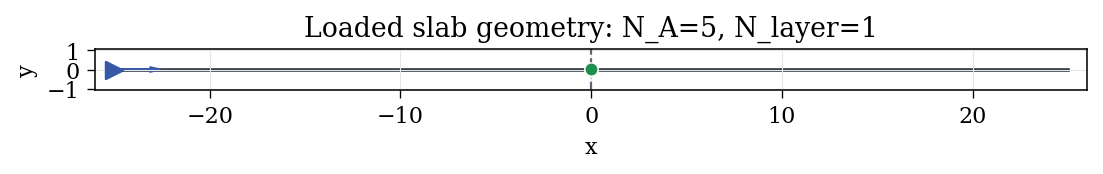

In [28]:
fig, ax = plt.subplots(figsize=(8.0, 2.2), dpi=resol)
if loaded_geometry_kind == "disk":
    plot_fiber_geometry(
        ax,
        L1=L1,
        L2=L2,
        atom_positions=atom_positions,
        interface_radius=geometry["interface_radius"],
        photon_position=(-L1 / 2, 0.0),
    )
    ax.set_title(f"Loaded disk geometry: N_A={geometry['N_A']}, R={geometry['interface_radius']:g}")
else:
    plot_slab_geometry(
        ax,
        L1=L1,
        L2=L2,
        atom_positions=atom_positions,
        n_layers=geometry["N_layer"],
        photon_position=(-L1 / 2, 0.0),
    )
    ax.set_title(f"Loaded slab geometry: N_A={geometry['N_A']}, N_layer={geometry['N_layer']}")
plt.show()


Choose the reference window, the uniform reference atom parameters, and the finite frequency calibration set.

The CSV stores one row for each `(omega_l, j, k)` component of the spectral kernel.


In [35]:
Omega = 10 * np.pi
d = 1.0
Omega_j = Omega * np.ones(geometry["N_A"])
d_j = d * np.ones(geometry["N_A"], dtype=float)

reference_cutoffs = {
    "ir_cutoff": 0 * np.pi,
    "uv_cutoff": 20 * np.pi,
}

nb_omega = 50
omega_values = np.linspace(Omega - 2 * abs(d) ** 2, Omega + 2 * abs(d) ** 2, nb_omega)

frequency_set = make_frequency_grid(omega_values)
radius_cache_decimals = 4 if loaded_geometry_kind == "slab" else 12

print(f"N_omega = {len(frequency_set)}")
print(f"N_spectral_entries = {len(frequency_set) * geometry['N_A'] ** 2}")
print(f"W_omega = {frequency_set['W_omega'].iloc[0]:.6g}")
print(f"W_ljk = {frequency_set['W_omega'].iloc[0] / geometry['N_A'] ** 2:.6g}")
print(f"radius_cache_decimals = {radius_cache_decimals}")
frequency_set.head()


N_omega = 50
N_spectral_entries = 1250
W_omega = 0.02
W_ljk = 0.0008
radius_cache_decimals = 4


,omega,W_omega
0,29.415927,0.02
1,29.497559,0.02
2,29.579192,0.02
3,29.660824,0.02
4,29.742457,0.02


In [36]:
target_profile = generate_target_profile(
    frequency_set,
    atom_positions=atom_positions,
    Omega_j=Omega_j,
    d_j=d_j,
    reference_cutoffs=reference_cutoffs,
    epsabs=1e-7,
    epsrel=1e-7,
    cache_decimals=radius_cache_decimals,
    progress=True,
)

target_profile.head()


target spectral profile:   0%|          | 0/50 [00:00<?, ?omega/s]

,omega,j,k,W,F_real,F_imag,reference_Omega,reference_d
0,29.415927,0,0,0.0008,-0.181698,-0.093985,31.415927,1.0
1,29.415927,0,1,0.0008,0.294263,0.124353,31.415927,1.0
2,29.415927,0,2,0.0008,-0.092315,0.008341,31.415927,1.0
3,29.415927,0,3,0.0008,-0.214513,-0.142305,31.415927,1.0
4,29.415927,0,4,0.0008,0.215965,0.055655,31.415927,1.0


In [37]:
if loaded_geometry_kind == "disk":
    geometry_label = f"NA{geometry['N_A']}_R{radius_label(geometry['interface_radius'])}"
else:
    geometry_label = f"NA{geometry['N_A']}_NL{geometry['N_layer']}"

window_label = (
    f"ref_{reference_cutoffs['ir_cutoff'] / np.pi:g}pi_"
    f"{reference_cutoffs['uv_cutoff'] / np.pi:g}pi"
).replace(".", "p")
output_dir = project_root / "2d_setup" / "generate_target_profile"
output_path = output_dir / f"target_profile_{geometry_label}_{window_label}.csv"

save_target_profile_csv(target_profile, output_path)
print(f"Saved target profile to: {output_path}")


Saved target profile to: /Users/romainpiron/Documents/NII_local/waveguide-qed-simulator/2d_setup/generate_target_profile/target_profile_NA5_NL1_ref_0pi_20pi.csv
